# Fit Smart - EDA & Dataset

**Tujuan:** Menghasilkan dataset bersih dengan 24 label makanan beserta info kalori, protein, lemak, dan karbohidrat.

Alur:
1. Download dataset otomatis dari Google Drive (public link)
2. Deteksi 24 label dari folder gambar
3. Match & ambil nilai nutrisi dari CSV
4. EDA ringkas (distribusi kalori, nutrisi, kualitas data)
5. Simpan dataset final ke CSV

---

##  Konfigurasi

In [ ]:
#  Link download dataset (Google Drive — public)
URL_IMAGES_ZIP   = 'https://drive.google.com/uc?id=1fTIbuFDclnZobr0_EQG9M6elgD-pJyh4'
# Force export format for CSV to avoid HTML wrapper
URL_NUTRITION_CSV = 'https://drive.google.com/uc?export=download&id=1KSpvR7QK7bOBGHK0JPe4Dlpbh3unqnjb'

# konfigurasi lokal
import os
BASE_DIR      = '/content/fitsmart'
IMAGES_DIR    = f'{BASE_DIR}/images'
NUTRITION_CSV = f'{BASE_DIR}/nutrition.csv'
OUTPUT_DIR    = f'{BASE_DIR}/output'

for d in [BASE_DIR, IMAGES_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

COL_NAME_OVERRIDE = None
COL_CAL_OVERRIDE  = None

MATCH_THRESHOLD        = 80
MATCH_THRESHOLD_STRICT = 92

print('✅ Konfigurasi berhasil')

✅ Konfigurasi berhasil


##  1. Install Library & Download Dataset

In [ ]:
!pip install -q thefuzz[speedup] gdown pandas pillow matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 102.0 MB/s eta 0:00:00


In [ ]:
import os, warnings, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from thefuzz import fuzz
import gdown

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')


In [ ]:
# Download nutrition CSV
print('📥 Downloading nutrition CSV...')
gdown.download(URL_NUTRITION_CSV, NUTRITION_CSV, quiet=False)
assert os.path.exists(NUTRITION_CSV), '❌ Download CSV gagal. Cek URL_NUTRITION_CSV di cell konfigurasi.'
print(f'✅ nutrition.csv tersimpan di {NUTRITION_CSV}')

📥 Downloading nutrition CSV...


Downloading...
From: https://drive.google.com/uc?export=download&id=1KSpvR7QK7bOBGHK0JPe4Dlpbh3unqnjb
To: /content/fitsmart/nutrition.csv
100%|██████████| 195k/195k [00:00<00:00, 96.9MB/s]

✅ nutrition.csv tersimpan di /content/fitsmart/nutrition.csv


In [ ]:
# Download & extract folder gambar
ZIP_PATH = f'{BASE_DIR}/images.zip'

print('Downloading dataset gambar...')
gdown.download(URL_IMAGES_ZIP, ZIP_PATH, quiet=False)

print('Extracting...')
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(IMAGES_DIR)
except zipfile.BadZipFile:
    print(f'ERROR: File yang diunduh bukan ZIP yang valid.')
    print(f'Pastikan URL_IMAGES_ZIP menggunakan format download langsung: https://drive.google.com/uc?id=FILE_ID')
    if os.path.exists(ZIP_PATH): os.remove(ZIP_PATH)
    raise

# Hapus zip setelah extract untuk hemat space
os.remove(ZIP_PATH)

# Cek hasil extract
extracted = [d for d in Path(IMAGES_DIR).iterdir() if d.is_dir()]
if len(extracted) == 1 and len(list(extracted[0].iterdir())) > 1:
    inner = extracted[0]
    for item in inner.iterdir():
        shutil.move(str(item), IMAGES_DIR)
    inner.rmdir()
    print(f'   (Folder container dirapikan)')

n_classes = len([d for d in Path(IMAGES_DIR).iterdir() if d.is_dir()])
print(f'Dataset gambar siap: {n_classes} folder ditemukan.')

Downloading...
From (original): https://drive.google.com/uc?id=1fTIbuFDclnZobr0_EQG9M6elgD-pJyh4
From (redirected): https://drive.google.com/uc?id=1fTIbuFDclnZobr0_EQG9M6elgD-pJyh4&confirm=t&uuid=a5487320-e555-4de5-9685-c73b62559204
To: /content/fitsmart/images.zip
100%|██████████| 534M/534M [00:03<00:00, 140MB/s]


Extracting...
   (Folder container dirapikan)
Dataset gambar siap: 24 folder ditemukan.


---
## 2. Deteksi 24 Label dari Folder Gambar


In [ ]:
img_dir   = Path(IMAGES_DIR)
supported = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

cls_dirs = {}
for d in sorted(img_dir.iterdir()):
    if d.is_dir():
        n_imgs = len([f for f in d.iterdir() if f.suffix.lower() in supported])
        cls_dirs[d.name] = {'path': d, 'n_imgs': n_imgs}

print(f'Total subfolder ditemukan : {len(cls_dirs)}')
print()
print(f'{"Kelas":40s} {"Jumlah gambar":>15}')
print('-' * 57)
for name, info in cls_dirs.items():
    print(f'{name:40s} {info["n_imgs"]:>15,}')
total_imgs = sum(v['n_imgs'] for v in cls_dirs.values())
print('-' * 57)
print(f'{"TOTAL":40s} {total_imgs:>15,}')

Total subfolder ditemukan : 24

Kelas                                      Jumlah gambar
---------------------------------------------------------
Ayam Goreng                                          400
Ikan Goreng                                          125
Mie Goreng                                           119
alpukat                                               60
apel                                                  40
bakso                                                315
bayam                                                 97
bebek_betutu                                         238
gado_gado                                            263
gudeg                                                213
jeruk                                                 40
kentang                                               77
mangga                                                39
nasi_goreng                                          366
pempek                                               28

In [ ]:
N_EXPECTED = 24
n_found    = len(cls_dirs)

if n_found == N_EXPECTED:
    print(f'Tepat {N_EXPECTED} label ditemukan — sesuai target!')
elif n_found < N_EXPECTED:
    print(f'Hanya {n_found} label ditemukan ({N_EXPECTED - n_found} kurang).')
    print('   Periksa apakah file ZIP sudah berisi semua 24 folder kelas.')
else:
    print(f'Ditemukan {n_found} label (lebih dari {N_EXPECTED}).')
    print('   Notebook akan memproses semua label yang ada.')

LABELS = sorted(cls_dirs.keys())
print(f'\nDaftar label ({len(LABELS)}):')
for i, lbl in enumerate(LABELS, 1):
    print(f'  {i:2d}. {lbl}')

Tepat 24 label ditemukan — sesuai target!

Daftar label (24):
   1. Ayam Goreng
   2. Ikan Goreng
   3. Mie Goreng
   4. alpukat
   5. apel
   6. bakso
   7. bayam
   8. bebek_betutu
   9. gado_gado
  10. gudeg
  11. jeruk
  12. kentang
  13. mangga
  14. nasi_goreng
  15. pempek
  16. pisang
  17. rawon
  18. rendang
  19. sate
  20. semangka
  21. soto
  22. tomat
  23. ubi
  24. wortel


---
## 🧾 3. Load & Bersihkan Nutrition CSV

In [ ]:
# Re-download and Load
print('Re-downloading nutrition CSV...')
if os.path.exists(NUTRITION_CSV): os.remove(NUTRITION_CSV)
gdown.download(URL_NUTRITION_CSV, NUTRITION_CSV, quiet=True)

try:
    df_raw = pd.read_csv(NUTRITION_CSV)
    print(f'Berhasil load CSV: {df_raw.shape[0]} baris')
except Exception as e:
    print(f'Gagal load CSV: {e}')
    # Fallback jika masih terdownload HTML
    with open(NUTRITION_CSV, 'r') as f: print(f'Pratinjau isi file: {f.read(200)}...')

df_raw.head(5)

Re-downloading nutrition CSV...
Berhasil load CSV: 1346 baris


,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


In [ ]:
def find_col(df, keywords):
    # Prioritize clean, exact matches
    for kw in keywords:
        for col in df.columns:
            if str(kw).lower() == str(col).lower().strip():
                return col
    # Fallback to substring matching if needed
    for kw in keywords:
        for col in df.columns:
            if str(kw).lower() in str(col).lower():
                return col
    return None

# Detect columns using the successfully loaded df_raw
COL_NAME = COL_NAME_OVERRIDE or find_col(df_raw, ['name','nama','food','makanan'])
COL_CAL  = COL_CAL_OVERRIDE  or find_col(df_raw, ['calories','kalori','kcal','energy','energi'])
COL_PROT = find_col(df_raw, ['proteins', 'protein'])
COL_FAT  = find_col(df_raw, ['fat','lemak','lipid'])
COL_CARB = find_col(df_raw, ['carbohydrate','karbo','carb','sugar','gula'])

print('=== Kolom terdeteksi ===')
for label, col in [('Nama',COL_NAME),('Kalori',COL_CAL),
                   ('Protein',COL_PROT),('Lemak',COL_FAT),('Karbo',COL_CARB)]:
    print(f'  {label:10s}: {col or "☐  tidak ditemukan"}')

assert COL_NAME and COL_CAL, '❌ Kolom nama/kalori tidak ditemukan. Harap periksa struktur CSV.'
print('Deteksi kolom berhasil!')

=== Kolom terdeteksi ===
  Nama      : name
  Kalori    : calories
  Protein   : proteins
  Lemak     : fat
  Karbo     : carbohydrate
Deteksi kolom berhasil!


In [ ]:
df_csv = df_raw.copy()

for col in [COL_CAL, COL_PROT, COL_FAT, COL_CARB]:
    if col:
        df_csv[col] = pd.to_numeric(df_csv[col], errors='coerce')

before = len(df_csv)
df_csv = df_csv[df_csv[COL_CAL] > 0].dropna(subset=[COL_CAL, COL_NAME])
print(f'Drop kalori kosong/0 : -{before - len(df_csv)} baris')

df_csv[COL_NAME] = (df_csv[COL_NAME].astype(str)
    .str.lower().str.strip()
    .str.replace(r'\s+', ' ', regex=True))

agg = {COL_CAL: 'mean'}
if COL_PROT: agg[COL_PROT] = 'mean'
if COL_FAT:  agg[COL_FAT]  = 'mean'
if COL_CARB: agg[COL_CARB] = 'mean'
before = len(df_csv)
df_csv = df_csv.groupby(COL_NAME, as_index=False).agg(agg)
print(f'Agregasi duplikat    : -{before - len(df_csv)} baris')

for col in [COL_CAL, COL_PROT, COL_FAT, COL_CARB]:
    if col:
        df_csv[col] = df_csv[col].round(1)

print(f'\n✅ CSV bersih: {len(df_csv):,} item unik siap di-match')

Drop kalori kosong/0 : -1 baris
Agregasi duplikat    : -3 baris

✅ CSV bersih: 1,342 item unik siap di-match


---
## 🔗 4. Smart Match: Label Folder → Nutrisi CSV

In [ ]:
COOKING_WORDS = {
    'goreng','rebus','bakar','kukus','panggang','tumis','oseng',
    'semur','masak','segar','mentah','matang','bumbu','saus',
    'kuah','kering','basah','manis','asin','pedas','original'
}

def extract_key(name: str) -> str:
    words = name.lower().replace('_', ' ').split()
    for w in words:
        if w not in COOKING_WORDS and len(w) > 2:
            return w
    return words[0]

def smart_match_label(folder_label: str, csv_names: list) -> tuple:
    key   = extract_key(folder_label)
    fname = folder_label.replace('_', ' ')
    candidates = [n for n in csv_names if key in n]
    thr = MATCH_THRESHOLD
    if not candidates:
        candidates = csv_names
        thr = MATCH_THRESHOLD_STRICT
    best, best_score = None, 0
    for c in candidates:
        s = fuzz.token_set_ratio(fname, c)
        if s > best_score:
            best, best_score = c, s
    if best_score >= thr:
        return best, best_score, 'matched'
    return best, best_score, 'no_match'

print('Fungsi smart_match_label siap')

Fungsi smart_match_label siap


In [ ]:
csv_names = df_csv[COL_NAME].tolist()

match_results = []
for label in LABELS:
    csv_name, score, status = smart_match_label(label, csv_names)
    match_results.append({'label': label, 'csv_name': csv_name,
                          'score': score, 'status': status})

df_match = pd.DataFrame(match_results)
matched  = df_match[df_match['status'] == 'matched']
no_match = df_match[df_match['status'] == 'no_match']

print(f'Matched   : {len(matched)} / {len(LABELS)} label')
print(f'No match  : {len(no_match)} label')
print()
print(f'{"Label Folder":35s} {"Match CSV":35s} {"Skor":>6} {"Status"}')
print('-' * 85)
for _, row in df_match.sort_values('score', ascending=False).iterrows():
    icon = '✅' if row['status'] == 'matched' else '❌'
    print(f"{icon} {row['label']:33s} {str(row['csv_name']):35s} {row['score']:>6} {row['status']}")

Matched   : 23 / 24 label
No match  : 1 label

Label Folder                        Match CSV                             Skor Status
-------------------------------------------------------------------------------------
✅ Ayam Goreng                       ayam                                   100 matched
✅ Ikan Goreng                       ikan asin bilis goreng                 100 matched
✅ Mie Goreng                        kerupuk mie kuning goreng              100 matched
✅ alpukat                           alpukat segar                          100 matched
✅ apel                              apel                                   100 matched
✅ bakso                             bakso                                  100 matched
✅ bayam                             bayam kukus                            100 matched
✅ gado_gado                         gado-gado                              100 matched
✅ rawon                             rawon masakan                          100 matche

In [ ]:
MANUAL_OVERRIDE = {
    # contoh:
    # 'nasi_goreng': 'nasi goreng spesial',
    # 'ayam_bakar' : 'ayam bakar bumbu kecap',
}

if MANUAL_OVERRIDE:
    for folder_label, csv_name in MANUAL_OVERRIDE.items():
        idx = df_match[df_match['label'] == folder_label].index
        if len(idx):
            df_match.loc[idx, 'csv_name'] = csv_name
            df_match.loc[idx, 'score']    = 100
            df_match.loc[idx, 'status']   = 'matched'
            print(f'✅ Override: "{folder_label}" → "{csv_name}"')
        else:
            print(f'⚠️  Label "{folder_label}" tidak ditemukan')

matched  = df_match[df_match['status'] == 'matched']
no_match = df_match[df_match['status'] == 'no_match']
print(f'\n✅ Final matched: {len(matched)} / {len(LABELS)} label')

if len(no_match) > 0:
    print(f'\n❌ Masih ada {len(no_match)} label belum match:')
    for _, r in no_match.iterrows():
        print(f'   - "{r["label"]}" (best attempt: "{r["csv_name"]}" score={r["score"]})')
    print('   → Isi MANUAL_OVERRIDE di atas lalu run ulang cell ini')


✅ Final matched: 23 / 24 label

❌ Masih ada 1 label belum match:
   - "bebek_betutu" (best attempt: "bebek (itik)" score=67)
   → Isi MANUAL_OVERRIDE di atas lalu run ulang cell ini


---
##  5. Bangun Dataset Final 24 Label

In [ ]:
rows = []
for _, mrow in matched.iterrows():
    csv_row = df_csv[df_csv[COL_NAME] == mrow['csv_name']]
    if csv_row.empty:
        print(f'⚠️  "{mrow["csv_name"]}" tidak ditemukan di CSV — skip')
        continue
    r = csv_row.iloc[0]
    rows.append({
        'label'    : mrow['label'],
        'csv_name' : mrow['csv_name'],
        'n_images' : cls_dirs[mrow['label']]['n_imgs'],
        'calories' : round(r[COL_CAL], 1),
        'protein'  : round(r[COL_PROT], 1) if COL_PROT else None,
        'fat'      : round(r[COL_FAT],  1) if COL_FAT  else None,
        'carbs'    : round(r[COL_CARB], 1) if COL_CARB else None,
    })

df_final = pd.DataFrame(rows).sort_values('label').reset_index(drop=True)
df_final.index += 1

print('Dataset final: {len(df_final)} label\n')
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_colwidth', 40)
display(df_final)

Dataset final: {len(df_final)} label



,label,csv_name,n_images,calories,protein,fat,carbs
1,Ayam Goreng,ayam,400,302.0,18.2,25.0,0.0
2,Ikan Goreng,ikan asin bilis goreng,125,380.0,33.6,27.5,0.0
3,Mie Goreng,kerupuk mie kuning goreng,119,476.0,0.1,21.1,71.3
4,alpukat,alpukat segar,60,85.0,0.9,6.5,7.7
5,apel,apel,40,58.0,0.3,0.4,14.9
6,bakso,bakso,315,76.0,4.1,2.5,9.2
7,bayam,bayam kukus,97,30.0,1.3,0.7,5.8
8,gado_gado,gado-gado,263,137.0,6.1,3.2,21.0
9,gudeg,gudeg,213,53.0,1.6,1.6,8.8
10,jeruk,jeruk bali,40,48.0,0.6,0.2,12.4


In [ ]:
missing_nutri = df_final[['protein','fat','carbs']].isnull().sum()
if missing_nutri.sum() > 0:
    print('Ada nilai nutrisi yang kosong:')
    print(missing_nutri[missing_nutri > 0])
    display(df_final[df_final[['protein','fat','carbs']].isnull().any(axis=1)])
    print('→ Isi MANUAL_OVERRIDE atau perbaiki matching ke CSV yang lebih lengkap')
else:
    print('Semua nilai nutrisi lengkap!')

Semua nilai nutrisi lengkap!


---
## 📊 6. EDA Dataset Final

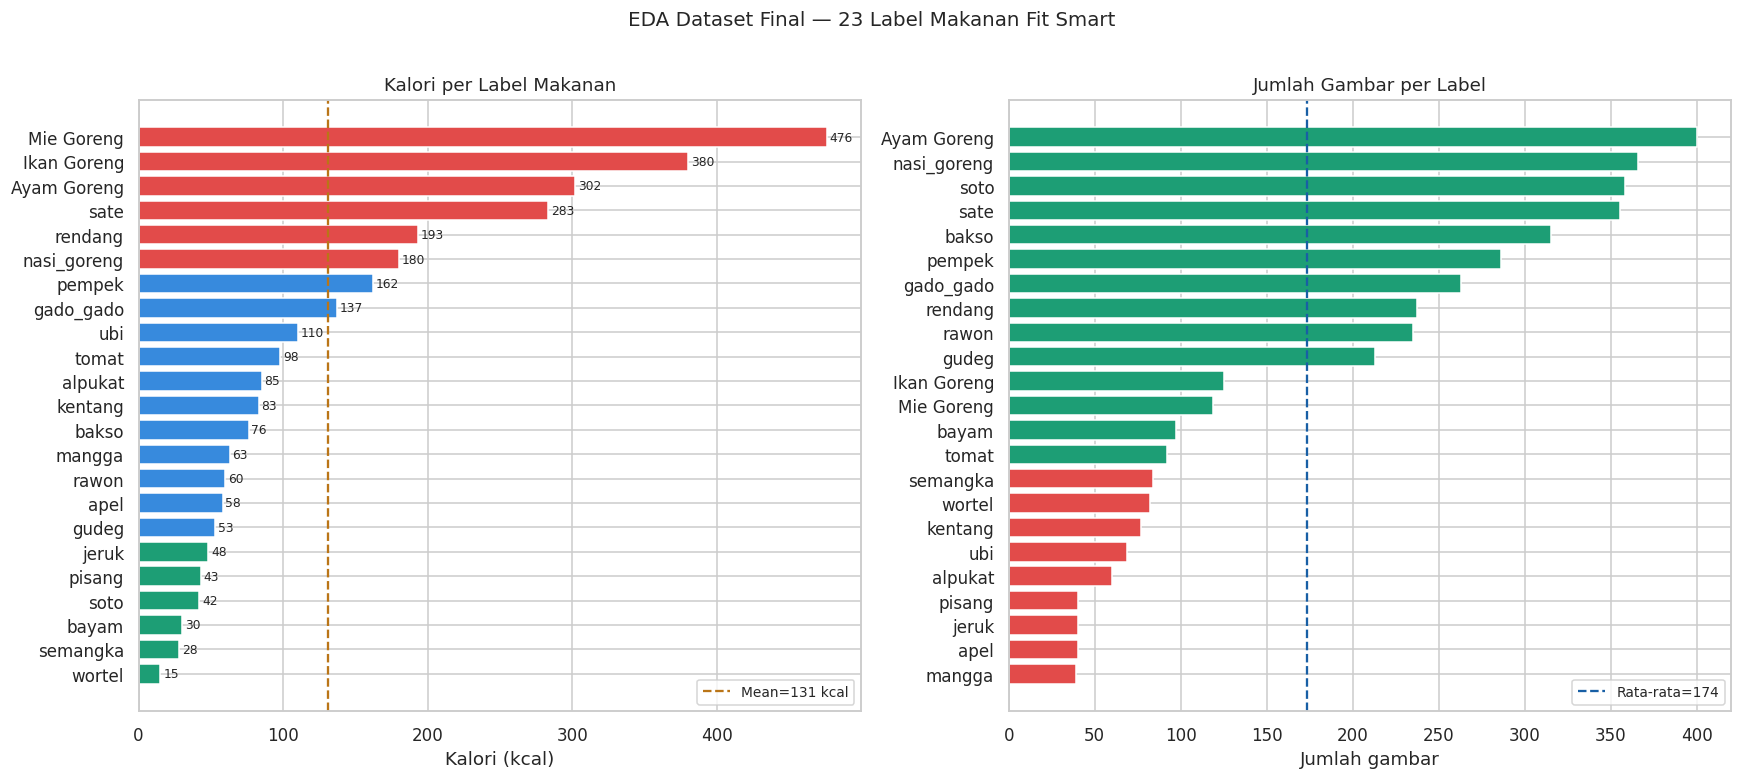

Plot disimpan


In [ ]:
df_plot = df_final.sort_values('calories')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#E24B4A' if c > df_final['calories'].quantile(0.75)
          else '#1D9E75' if c < df_final['calories'].quantile(0.25)
          else '#378ADD' for c in df_plot['calories']]
bars = axes[0].barh(df_plot['label'], df_plot['calories'], color=colors, edgecolor='white')
axes[0].axvline(df_final['calories'].mean(), color='#BA7517', linestyle='--',
                linewidth=1.5, label=f'Mean={df_final["calories"].mean():.0f} kcal')
axes[0].set_xlabel('Kalori (kcal)')
axes[0].set_title('Kalori per Label Makanan')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, df_plot['calories']):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}', va='center', fontsize=8)

df_imgs = df_final.sort_values('n_images')
mean_img = df_final['n_images'].mean()
img_colors = ['#E24B4A' if v < mean_img * 0.5 else '#1D9E75' for v in df_imgs['n_images']]
axes[1].barh(df_imgs['label'], df_imgs['n_images'], color=img_colors, edgecolor='white')
axes[1].axvline(mean_img, color='#185FA5', linestyle='--',
                linewidth=1.5, label=f'Rata-rata={mean_img:.0f}')
axes[1].set_xlabel('Jumlah gambar')
axes[1].set_title('Jumlah Gambar per Label')
axes[1].legend(fontsize=9)

plt.suptitle(f'EDA Dataset Final — {len(df_final)} Label Makanan Fit Smart', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_24label.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan')

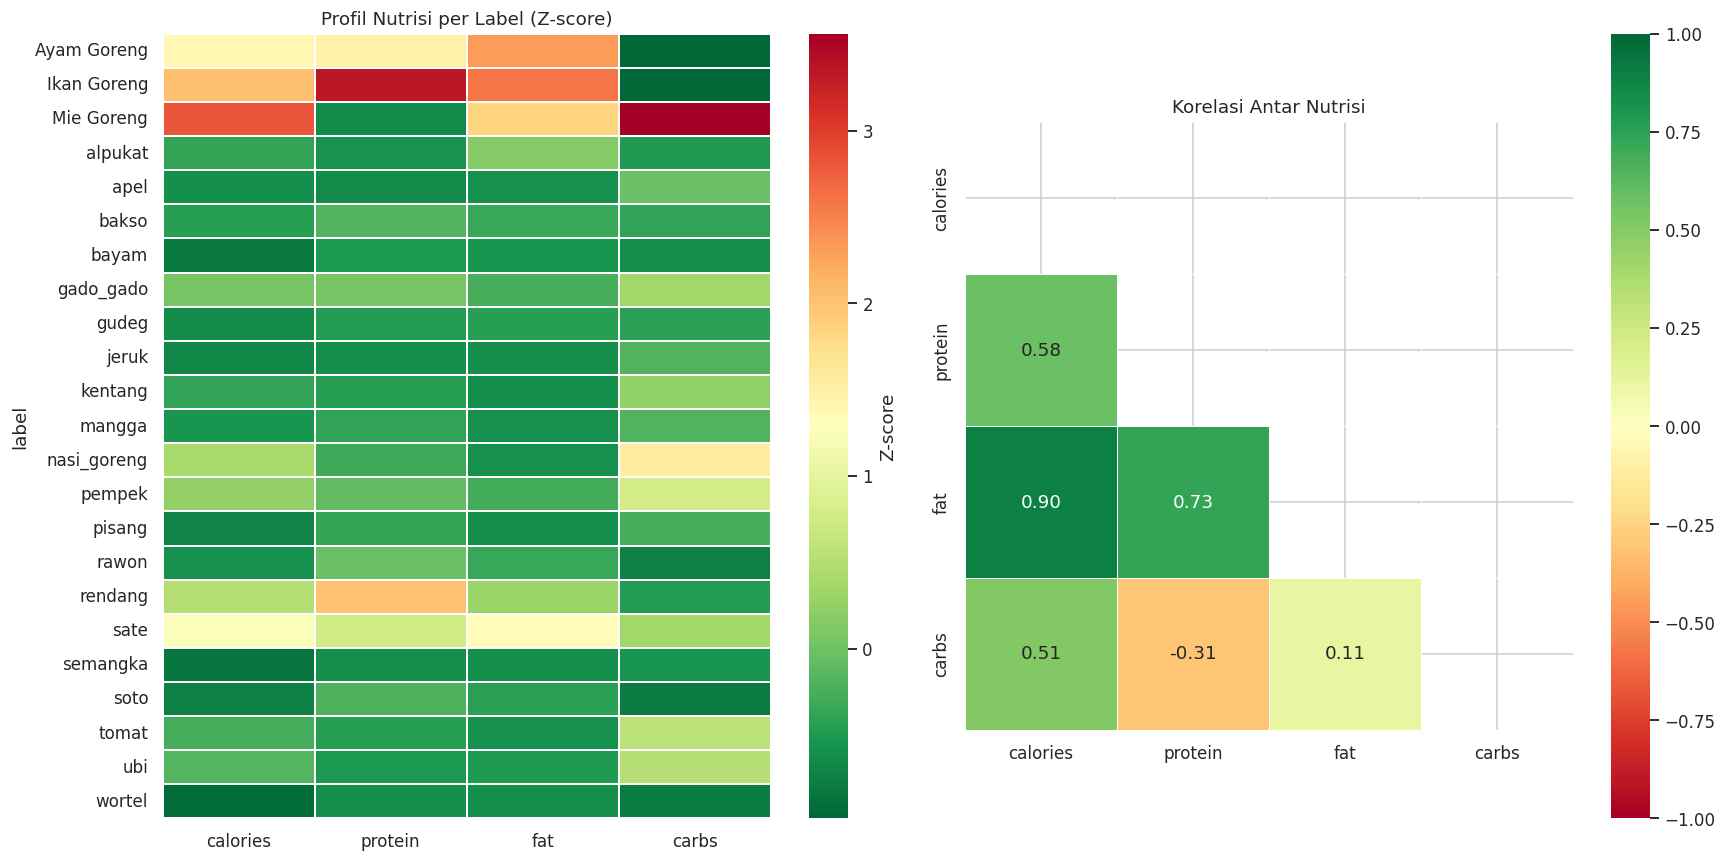

In [ ]:
nutri_cols = [c for c in ['calories','protein','fat','carbs'] if df_final[c].notna().all()]

if len(nutri_cols) >= 2:
    df_heatmap = df_final.set_index('label')[nutri_cols]
    df_norm = (df_heatmap - df_heatmap.mean()) / (df_heatmap.std() + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    sns.heatmap(df_norm, ax=axes[0], cmap='RdYlGn_r', annot=False,
                linewidths=0.3, cbar_kws={'label': 'Z-score'})
    axes[0].set_title('Profil Nutrisi per Label (Z-score)')
    axes[0].set_xlabel('')

    corr = df_heatmap.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, mask=mask, linewidths=0.5, square=True, vmin=-1, vmax=1)
    axes[1].set_title('Korelasi Antar Nutrisi')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/nutrisi_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️  Tidak cukup kolom nutrisi untuk heatmap.')

In [ ]:
print('=== Statistik Dataset Final ===')
print(f'  Jumlah label  : {len(df_final)}')
print(f'  Total gambar  : {df_final["n_images"].sum():,}')
print(f'  Gambar/label  : min={df_final["n_images"].min()} | max={df_final["n_images"].max()} | rata-rata={df_final["n_images"].mean():.0f}')
print()
print(f'  Kalori : {df_final["calories"].min():.0f}–{df_final["calories"].max():.0f} kcal (mean={df_final["calories"].mean():.0f})')
if COL_PROT: print(f'  Protein: {df_final["protein"].min():.1f}–{df_final["protein"].max():.1f} g (mean={df_final["protein"].mean():.1f})')
if COL_FAT:  print(f'  Lemak  : {df_final["fat"].min():.1f}–{df_final["fat"].max():.1f} g (mean={df_final["fat"].mean():.1f})')
if COL_CARB: print(f'  Karbo  : {df_final["carbs"].min():.1f}–{df_final["carbs"].max():.1f} g (mean={df_final["carbs"].mean():.1f})')
print(f'\n  🏆 Tertinggi : {df_final.loc[df_final["calories"].idxmax(), "label"]} ({df_final["calories"].max():.0f} kcal)')
print(f'  🥗 Terendah  : {df_final.loc[df_final["calories"].idxmin(), "label"]} ({df_final["calories"].min():.0f} kcal)')

=== Statistik Dataset Final ===
  Jumlah label  : 23
  Total gambar  : 3,992
  Gambar/label  : min=39 | max=400 | rata-rata=174

  Kalori : 15–476 kcal (mean=131)
  Protein: 0.1–33.6 g (mean=5.7)
  Lemak  : 0.0–27.5 g (mean=5.4)
  Karbo  : 0.0–71.3 g (mean=15.4)

  🏆 Tertinggi : Mie Goreng (476 kcal)
  🥗 Terendah  : wortel (15 kcal)


---
##  7. Simpan Dataset Final

In [ ]:
import json
out_label = f'{OUTPUT_DIR}/dataset_24label_nutrisi.csv'
df_final.reset_index(drop=True).to_csv(out_label, index=False)
print(f'dataset_24label_nutrisi.csv  → {len(df_final)} baris')

records = []
labels_sorted = sorted(df_final['label'].tolist())
for _, row in df_final.iterrows():
    cls_dir = cls_dirs[row['label']]['path']
    imgs    = sorted([f for f in cls_dir.iterdir() if f.suffix.lower() in supported])
    for img in imgs:
        records.append({
            'image_path': str(img),
            'label'     : row['label'],
            'class_id'  : labels_sorted.index(row['label']),
            'calories'  : row['calories'],
            'protein'   : row['protein'],
            'fat'       : row['fat'],
            'carbs'     : row['carbs'],
        })

df_master = pd.DataFrame(records)
out_master = f'{OUTPUT_DIR}/dataset_24label_master.csv'
df_master.to_csv(out_master, index=False)
print(f'✅ dataset_24label_master.csv   → {len(df_master):,} baris (satu per gambar)')

cls2idx = {lbl: i for i, lbl in enumerate(labels_sorted)}
mapping = {
    'n_classes': len(cls2idx),
    'cls2idx'  : cls2idx,
    'idx2cls'  : {v: k for k, v in cls2idx.items()},
    'nutrition' : df_final.set_index('label')[['calories','protein','fat','carbs']]
                  .to_dict(orient='index'),
}
out_mapping = f'{OUTPUT_DIR}/class_mapping.json'
with open(out_mapping, 'w') as f:
    json.dump(mapping, f, indent=2, ensure_ascii=False)
print(f'class_mapping.json           → {len(cls2idx)} kelas')

print(f'Semua file tersimpan di: {OUTPUT_DIR}')

dataset_24label_nutrisi.csv  → 23 baris
✅ dataset_24label_master.csv   → 3,992 baris (satu per gambar)
class_mapping.json           → 23 kelas
Semua file tersimpan di: /content/fitsmart/output



## 8. Download Output ke Komputer Lokal

In [ ]:
# Zip semua output dan download
import shutil
from google.colab import files

zip_out = '/content/fitsmart_output'
shutil.make_archive(zip_out, 'zip', OUTPUT_DIR)
print(f'✅ Output di-zip: {zip_out}.zip')

print('\nFile yang tersedia untuk didownload:')
for f in Path(OUTPUT_DIR).iterdir():
    size = f.stat().st_size / 1024
    print(f'  {f.name:45s} {size:>8.1f} KB')

# Download zip
files.download(f'{zip_out}.zip')
print('Download dimulai...')

✅ Output di-zip: /content/fitsmart_output.zip

File yang tersedia untuk didownload:
  nutrisi_heatmap.png                              125.2 KB
  dataset_24label_master.csv                       298.6 KB
  class_mapping.json                                 3.4 KB
  dataset_24label_nutrisi.csv                        1.0 KB
  eda_24label.png                                  174.5 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download dimulai...


In [ ]:
# Tampilan akhir dataset
print('=== DATASET FINAL 24 LABEL — FIT SMART ===')
print()
display(df_final[['label','n_images','calories','protein','fat','carbs']]
        .rename(columns={
            'label'   : 'Label',
            'n_images': 'Jumlah Gambar',
            'calories': 'Kalori (kcal)',
            'protein' : 'Protein (g)',
            'fat'     : 'Lemak (g)',
            'carbs'   : 'Karbo (g)'
        })
        .sort_values('Kalori (kcal)', ascending=False)
        .reset_index(drop=True))

print(f'Selesai! Dataset siap digunakan untuk training Mode A.')

=== DATASET FINAL 24 LABEL — FIT SMART ===



,Label,Jumlah Gambar,Kalori (kcal),Protein (g),Lemak (g),Karbo (g)
0,Mie Goreng,119,476.0,0.1,21.1,71.3
1,Ikan Goreng,125,380.0,33.6,27.5,0.0
2,Ayam Goreng,400,302.0,18.2,25.0,0.0
3,sate,355,283.0,12.1,16.8,20.9
4,rendang,237,193.0,22.6,7.9,7.8
5,nasi_goreng,366,180.0,3.0,0.3,39.8
6,pempek,286,162.0,4.9,3.0,27.8
7,gado_gado,263,137.0,6.1,3.2,21.0
8,ubi,69,110.0,1.4,1.1,23.4
9,tomat,92,98.0,2.0,0.4,24.5


Selesai! Dataset siap digunakan untuk training Mode A.
